# Étude de la différence d'agentivité entre hommes et femmes dans la littérature  française du XIX <sup>e</sup> siècle  et début  du XX<sup>e</sup> siècle. 

**Auteure** : Echard Camille

**Date** : Mai 2026

**Il est  important de noter que des éléments présents dans le code qui suit ont pu être produits par IA générative (Gemini)**

##### $Quelle\ est\ la\ magnitude\ de\ la\ différence\ d'agentivité\ entre\ les\ genres\ dans\ la\ littérature\ \text{française}\ du\ XIXe\ siècle\ ?$

Le XIXe siècle constitue une période de codification intense des rôles de genre, marquée par une relégation fréquente des femmes à la sphère privée et à une forme de passivité juridique et sociale. Interroger la magnitude de cette différence d'agentivité dans les récits de l'époque permet de comprendre dans quelle mesure la création littéraire se fait le miroir des rapports de domination réels, ou si elle offre au contraire un espace de négociation et de subversion face aux contraintes sociales imposées aux femmes.

Cette étude s'inspire de l'article *The gender agency gap in fiction writing (1850 to 2010)* d'Oscar Stuhler publié en 2024, dans le but d'en reproduire l'idée sur un corpus de littérature française. 

Avec la difficulté de trouver un tel corpus de textes français du XIX<sup>e</sup> au  XXI<sup>e</sup> siècle, le projet a  été réduit en fonction des données  récupérées. Les données utilisées dans cette étude ont été scrappées du site du Projet Gutenberg, dans la catégorie French Literature, en filtrant et en vérifiant que le  texte est bien en français (certaines oeuvres dans la catégorie French Literature sont en anglais). J'ai donc récupéré 660 textes au format .txt, formatés par le Projet Gutenberg. 

Pour pouvoir réaliser l'analyse, en se basant sur des triplets sujet-verbe-objet, les fichiers ont été modifiés pour créer un jeu de données. Ainsi, dans la  partie 2 de ce notebook, j'ai fait une première analyse des textes  pour créer un jeu de données avec les colonnes *sujet*, *genre du sujet*, *verbe*, *objet du verbe*, *voix* (active ou passive), *annee*, *auteur*, *fichier*. J'ai commencé par nettoyer les fichiers des parties de texte rajoutées par le Pojet Gutenberg, problème récurrent en utilisant cette source, avec la fonction simple_cleaner de la bibliothèque gutenbger_cleaner, pour n'avoir dans le fichier que le texte de l'oeuvre en elle-même. 

Pour récupérer le genre des sujets désignés par un nom propre et non un pronom (dont  le genre est facilement identifiable), j'ai créé la fonction construire_lexique_global qui extraie le nom des personnages des textes mais surtout déduit leur genre en fonction du contexte grammatical qui les entoure.
J'ai ensuite écrit la fonction extraire_triplets_precis pour extraire les triplets SVO précis en intégrant le genre du sujet pour chacun puis la fonction traiter_corpus qui, à partir des noms de fichiers de la forme ANNEE_AUTEUR.txt, récupère l'année de publication et l'auteur du texte et qui crée le jeu de données final comme décrit précédemment pour le reste de l'analyse. 

Finalement, dans la partie 3, j'ai pu analyser à quel point un pesonnage féminin avait plus ou moins de chance d'être  sujet d'un verbe actif qu'un personnage masculin. J'ai effectué deux analyses, qui diffèrent par la liste de verbes et d'objets que je n'ai pas comptabilisés dans le calcul des verbes et des objets les plus fréquents par genre. 

## 1. Importation des bibliothèques

In [1]:
import spacy 
from spacy import displacy 
import pandas as pd 
from tqdm.notebook import tqdm 
import matplotlib.pyplot as plt 
import seaborn as sns 
import nltk 
from gutenberg_cleaner import simple_cleaner
import os
from pathlib import Path
import spacy.cli
import scipy.stats as stats
from collections import Counter

nltk.download('punkt') 

sns.set(context = 'paper', style = 'ticks', font_scale = 1) 

[nltk_data] Downloading package punkt to /Users/Camille/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Charger le modèle français
spacy.cli.download("fr_core_news_md")

nlp = spacy.load("fr_core_news_md")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 3.8 MB/s  0:00:12m0:00:0100:01



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2. Création du  jeu de données

### 2.1. Nettoyage des fichiers Gutenberg

In [3]:
# Fonction pour nettoyer les fichiers du  projet Gutenberg qui ont toujours des informations rajoutées au texte par Gutenberg
def nettoyer_livre(chemin_entree, chemin_sortie): 
    try:
        with open(chemin_entree, 'r', encoding = 'utf-8') as f:
            texte_brut = f.read()
        
        # Nettoyage par gutenberg-cleaner
        texte_propre = simple_cleaner(texte_brut)
        
        # Nettoyage  des  retours à la ligne, pour un texte plus propre
        paragraphes = texte_propre.split('\n\n')
        texte_final = '\n\n'.join([p.replace('\n', ' ') for p in paragraphes])

        with open(chemin_sortie, 'w', encoding = 'utf-8') as f:
            f.write(texte_final)
        return True
    except Exception as e:
        print(f"Erreur sur {chemin_entree}: {e}")
        return False

dossier_source = "livres_gutenberg"
dossier_destination = "corpus"

if not os.path.exists(dossier_destination):
    os.makedirs(dossier_destination)

fichiers = [f for f in os.listdir(dossier_source) if f.endswith('.txt')]

if fichiers:
    # Test du  nettoyage d'abord sur un livre, pour vérifier
    nom_test = fichiers[0]
    nom_test_modifie = nom_test.replace(".txt", "_TEST.txt")
    
    nettoyer_livre(
        os.path.join(dossier_source, nom_test),
        os.path.join(dossier_destination, nom_test_modifie)
    )
    
    # Boucle sur tous les fichiers
    reponse = input("\nLancer le nettoyage sur tout le dossier ? (o/n) : ")
    
    if reponse.lower() == 'o':
        for nom_fichier in fichiers:
            chemin_in = os.path.join(dossier_source, nom_fichier)
            chemin_out = os.path.join(dossier_destination, nom_fichier)
            
            nettoyer_livre(chemin_in, chemin_out)
        
        print("\n Nettoyage fini.")
    else:
        print("Nettoyage annulée.")
    
else:
    print("Aucun fichier .txt trouvé.")



 Nettoyage fini.


### 2.2. Extraction du genre des personnages et des triplets SVO

In [5]:
# Fonction d'analyse du contexte grammatical des personnages pour déterminer leur genre, sur le premier million de personnages d'un livre

def construire_lexique_global(chemin_fichier):
    try:
        texte = Path(chemin_fichier).read_text(encoding = "utf-8")
        doc = nlp(texte[:1000000]) 
    except Exception:
        return {}
    
    lexique = {}
    points_genre = Counter()
    
    # Titres utilisés couramment, pour aider à déterminer le genre
    titres_m = {"monsieur", "m.", "comte", "marquis", "baron", "duc"}
    titres_f = {"madame", "mme", "comtesse", "marquise", "baronne", "duchesse"}

    for ent in doc.ents:
        if ent.label_ == "PER":
            nom = ent.text.lower().strip()
            for t in (titres_m | titres_f):
                nom = nom.replace(t, "").strip()
            
            if len(nom) < 2: continue
                
            # Déterminer le genre grâce à la liste de titres définie plus haut
            if ent.start > 0:
                precedent = doc[ent.start - 1].text.lower()
                if precedent in titres_m: points_genre[nom] += 25
                elif precedent in titres_f: points_genre[nom] -= 25
            
            # Déterminer le genre grâce à l'accord de l'adjectif associé au personnage
            prochain = doc[ent.end] if ent.end < len(doc) else None
            if prochain and (prochain.pos_ == "ADJ" or prochain.lemma_ in ["être", "sembler"]):
                for enfant in prochain.subtree:
                    if enfant.pos_ == "ADJ":
                        g = enfant.morph.get("Gender")
                        if "Fem" in g: points_genre[nom] -= 30
                        elif "Masc" in g: points_genre[nom] += 15

    for nom, score in points_genre.items():
        if score > 5: lexique[nom] = "M"
        elif score < -5: lexique[nom] = "F"
    
    return lexique

In [6]:
# Fonction d'extraction des triplets sujet-verbe-objet en identifiant le genre avec le lexique fourni par la fonction précédente

def extraire_triplets_precis(chemin_fichier, lexique):
    try:
        texte = Path(chemin_fichier).read_text(encoding = "utf-8")
    except Exception:
        return []

    paragraphes = [p.strip() for p in texte.split('\n\n') if len(p.strip()) > 20]
    resultats = []
    
    for doc in nlp.pipe(paragraphes, batch_size = 50):
        for token in doc:
            if token.pos_ == "VERB":
                subjects = [w for w in token.lefts if "nsubj" in w.dep_]
                objects = [w for w in token.rights if w.dep_ in ("obj", "iobj")]
                
                for s in subjects:
                    nom_brut = s.text.lower()
                    # Nettoyage pour correspondre au lexique
                    nom_nettoye = nom_brut.replace("monsieur ", "").replace("madame ", "").replace("m. ", "").replace("mme ", "").strip()
                    
                    genre = "Indéterminé"
                    if nom_nettoye in ["il", "ils"]: genre = "M"
                    elif nom_nettoye in ["elle", "elles"]: genre = "F"
                    elif nom_nettoye in lexique: genre = lexique[nom_nettoye]
                    
                    if genre != "Indéterminé":
                        # Création d'une ligne "NONE"  s'il n'y a pas d'objet, pour l'agentivité pure
                        targets = objects if objects else [None]
                        for o in targets:
                            obj_text = o.text.lower() if o else "NONE"
                            obj_humain = False
                            if o:
                                obj_nettoye = obj_text.replace("monsieur ", "").replace("madame ", "").strip()
                                obj_humain = (o.ent_type_ == "PER" or obj_nettoye in lexique or o.pos_ == "PRON")

                            resultats.append({
                                "sujet": nom_nettoye,
                                "sujet_genre": genre,
                                "verbe": token.lemma_,
                                "objet": obj_text,
                                "objet_humain": obj_humain,
                                "voix": "actif" if "pass" not in s.dep_ else "passif"
                            })
    return resultats

### 2.3. Création du jeu de  données final

In [ ]:
# Fonction finale de création du jeu de données, en traitant tout le corpus pour extraire les informations nécessaires et les stocker

def traiter_corpus(dossier_entree, fichier_csv_final):
    
    dossier = Path(dossier_entree)
    fichiers = list(dossier.glob("*.txt"))
    
    print(f"🚀 Début de l'analyse : {len(fichiers)} livres à traiter.")
    tous_les_triplets = []

    for i, chemin in enumerate(fichiers):
        
        # Extraction  des métadonnées des fichiers 
        nom_sans_ext = chemin.stem 
        parts = nom_sans_ext.split('_')
        annee = parts[0] if len(parts) > 0 else "Inconnue"
        auteur = parts[1] if len(parts) > 1 else "Inconnu"
        
        print(f"[{i+1}/{len(fichiers)}] {annee} - {auteur}...", end = " ", flush = True)
        
        # Traite le corpus avec la fonction précédente pour déterminer le genre et créer un dictionnaire des personnages, associés à leur genre
        lexique = construire_lexique_global(chemin)
        
        # Extrait les triplets SVO avec la fonction précédente
        triplets = extraire_triplets_precis(chemin, lexique)
        
        # AAssociation des triplets à leurs métadonnées correspondates
        for t in triplets:
            t['annee'] = annee
            t['auteur'] = auteur
            t['fichier'] = chemin.name
            tous_les_triplets.append(t)
        
        print(f"{len(triplets)} triplets.")

    # Sauvegarde de tous les résultats 
    if tous_les_triplets:
        df = pd.DataFrame(tous_les_triplets)
        df.to_csv(fichier_csv_final, index = False, encoding = 'utf-8-sig')
        print(f"\nFichier généré : {fichier_csv_final}")
    else:
        print("\nAucun triplet n'a pu être extrait.")


if __name__ == "__main__":
    traiter_corpus("corpus", "analyse_agentivite_600_livres.csv")

## 3. Analyse de l'agentivité

In [8]:
df =  pd.read_csv("analyse_agentivite_600_livres.csv")
df.head(10)

/var/folders/63/jnwplly51236mybv32ghbflc0000gp/T/ipykernel_34120/2354373464.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv("analyse_agentivite_600_livres.csv")


,sujet,sujet_genre,verbe,objet,objet_humain,voix,annee,auteur,fichier
0,il,M,tirer,NONE,False,passif,1917,Loti,1917_Loti.txt
1,il,M,pouvoir,NONE,False,actif,1917,Loti,1917_Loti.txt
2,ils,M,commencer,NONE,False,actif,1917,Loti,1917_Loti.txt
3,il,M,venir,NONE,False,actif,1917,Loti,1917_Loti.txt
4,il,M,faire,NONE,False,actif,1917,Loti,1917_Loti.txt
5,elles,F,exister,NONE,False,actif,1917,Loti,1917_Loti.txt
6,ils,M,concourir,NONE,False,actif,1917,Loti,1917_Loti.txt
7,il,M,falloir,NONE,False,actif,1917,Loti,1917_Loti.txt
8,ils,M,lancer,NONE,False,passif,1917,Loti,1917_Loti.txt
9,elle,F,connaître,NONE,False,actif,1917,Loti,1917_Loti.txt


### 3.1. Première analyse avec un premier choix de filtre de verbes et d'objets

#### 3.1.1. Listes de filtres

In [9]:
# Définition d'une liste de verbes à ne pas comptabiliser, du fait de leur fréquence très grande chez les femmes comme chez les hommes
# et de leur faible magnitude sur l'agentivité
stop_verbes = ['avoir', 'être', 'faire', 'pouvoir', 'vouloir', 'devoir', 
    'dire', 'voir', 'aller', 'falloir', 'savoir', 'paraître', 
    'sembler', 'venir', 'commencer', 'finir', 'mettre', 'prendre']

# Définition d'une liste d'objet qui apportent peu à l'étude de l'agentivité également
stop_objets = ['NONE', 'rien', 'point', 'pas', 'tout', 'ce', 'un', 'une', 'le', 'la', 'les', 'cela']

# Filtrage du jeu de données avec ces listes
df_clean = df[~df['verbe'].isin(stop_verbes)]
df_clean = df_clean[~df_clean['objet'].isin(stop_objets)]

#### 3.1.2. Calcul du ratio d'agentivité

In [10]:
# Comme une colonne du jeu de données est à valeurs booléennes pour savoir si c'est une situation où le sujet est agentif
# (avec un verbe agentif), on regroupe par genre et on calcule la moyenne de cette colonne 'est_agentif', True = 1, False = 0

ratios = (df_clean['voix'] == 'actif').groupby(df_clean['sujet_genre']).mean() * 100

print(f"Ratio de voix active Féminine : {ratios.get('F', 0):.2f}%")
print(f"Ratio de voix active Masculine : {ratios.get('M', 0):.2f}%\n")

Ratio de voix active Féminine : 99.44%
Ratio de voix active Masculine : 99.19%



#### 3.1.3. Test  statistique

In [11]:
# On vérifie si il  y a un lien significatif entre les résultats avec un test du Chi-2

# Création de la table de contingence, comme tableau croisé dynamique
table_contingence = pd.crosstab(df_clean['sujet_genre'], df_clean['voix'])
print("Table de contingence :")
print(table_contingence, "\n")

# Test du Chi-2
chi2, p_value, dof, expected = stats.chi2_contingency(table_contingence)

print(f"Valeur Chi-2 : {chi2:.4f}")
print(f"P-value : {p_value:.4f}")

Table de contingence :
voix          actif  passif
sujet_genre                
F             72524     409
M            171061    1393 

Valeur Chi-2 : 42.5471
P-value : 0.0000


#### 3.1.4. Calcul de l'ampleur du phénomène

In [13]:
# On vérifie l'ampleur de ce lien avec un odds ratio

try:
    # On isole les valeurs de la table de contingence pour le calcul d'après
    F_passif = table_contingence.loc['F', 'passif']
    F_actif = table_contingence.loc['F', 'actif']
    M_passif = table_contingence.loc['M', 'passif']
    M_actif = table_contingence.loc['M', 'actif']
    
    # Calcul de l'odds ratio
    odds_ratio = (F_actif * M_passif) / (F_passif * M_actif)
    
    print(f"Odds Ratio : {odds_ratio:.2f}")
    

    if odds_ratio > 1:
        print(f"-> Un personnage féminin a {odds_ratio:.2f} fois plus de chances d'être le sujet d'un verbe à la voix active qu'un personnage masculin.")
    else:
        print(f"-> Un personnage masculin a {1/odds_ratio:.2f} fois plus de chances d'être le sujet d'un verbe à la voix active qu'un personnage féminin.")
except KeyError:
    print("Vérifier le nom ded lignes ('F', 'M') ou des colonnes ('actif', 'passif'), elles ne correspondent pas à la table.")
except ZeroDivisionError:
    print("Division par zéro, une des cases de ta table (F_passif ou M_actif) vaut 0.")
except Exception as e:
    print(f"Une erreur imprévue est survenue : {e}")

Odds Ratio : 1.44
-> Un personnage féminin a 1.44 fois plus de chances d'être le sujet d'un verbe à la voix active qu'un personnage masculin.


#### 3.1.5. Analyse sémantique des verbes et objets les plus fréquents par genre

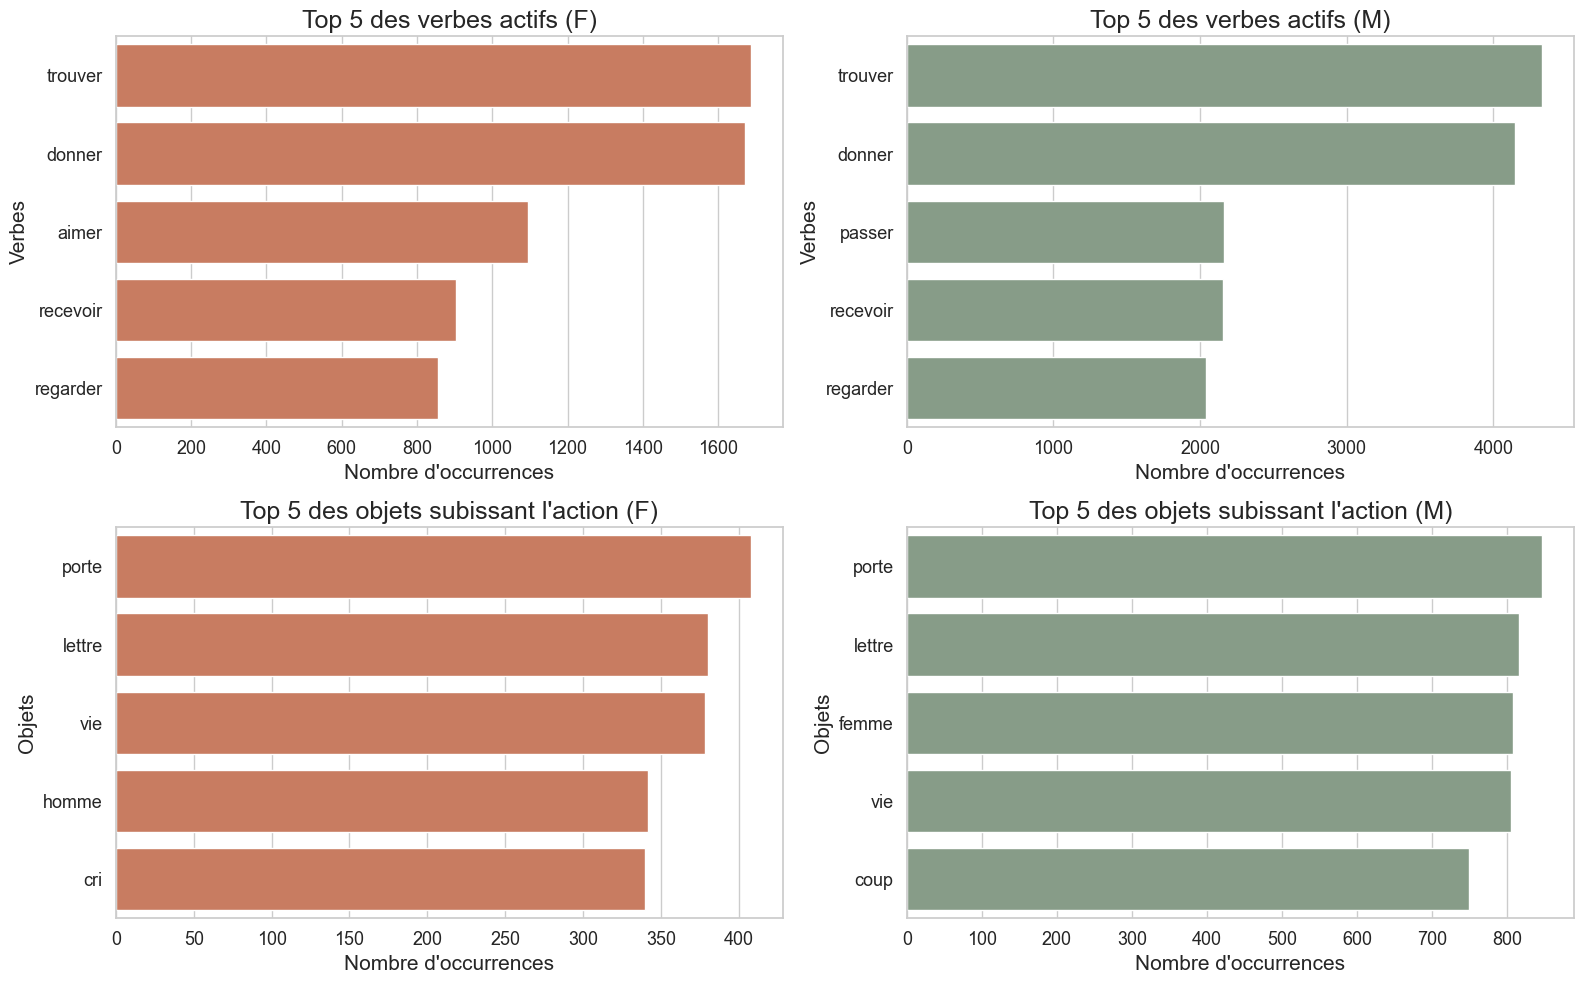

In [37]:
# On ne garde que les lignes où le verbe est agentif
df_actif = df_clean[df_clean['voix'] == 'actif']

# On configure le style général des graphiques
sns.set_theme(style = "whitegrid")
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Définition de couleurs distinctes pour le genre 
couleurs = {'F': '#d97450', 'M': '#83a085'}  

# Calcul des 5 verbes les plus fréquents quand chaque genre est agentif
for i, genre in enumerate(['F', 'M']):
    # Extraction des  verbes
    top_verbes = df_actif[df_actif['sujet_genre'] == genre]['verbe'].value_counts().head(5)
    
    # Création du graphique 
    sns.barplot(
        x = top_verbes.values, 
        y = top_verbes.index, 
        ax = axes[0, i], 
        color = couleurs[genre]
    )
    axes[0, i].set_title(f"Top 5 des verbes actifs ({genre})", fontsize = 18)
    axes[0, i].set_xlabel("Nombre d'occurrences", fontsize = 15)
    axes[0, i].set_ylabel("Verbes", fontsize = 15)
    axes[0, i].tick_params(axis='both', labelsize=13)

# Calcul des 5 objets les plus fréquents quand chaque genre est agentif
for i, genre in enumerate(['F', 'M']):
    # Extraction des objets
    top_objets = df_actif[df_actif['sujet_genre'] == genre]['objet'].value_counts().head(5)
    
    # Création du graphique
    sns.barplot(
        x = top_objets.values, 
        y = top_objets.index, 
        ax = axes[1, i], 
        color = couleurs[genre]
    )
    axes[1, i].set_title(f"Top 5 des objets subissant l'action ({genre})", fontsize = 18)
    axes[1, i].set_xlabel("Nombre d'occurrences", fontsize = 15)
    axes[1, i].set_ylabel("Objets", fontsize = 15)
    axes[1, i].tick_params(axis='both', labelsize=13)


plt.tight_layout()
plt.show()

On remarque que les objets  font tous référence à des parties du corps, on fait donc une deuxième analyse en les excluant, pour voir comment chaque genre intéragit avec le monde autour.

### 3.2. Deuxième analyse avec de nouveaux  filtres

#### 3.2.1. Listes des filtres

In [31]:
# Liste des verbes à ne pas comptabiliser
stop_verbes = ['avoir', 'être', 'faire', 'pouvoir', 'vouloir', 'devoir', 
    'dire', 'voir', 'aller', 'falloir', 'savoir', 'paraître', 
    'sembler', 'venir', 'commencer', 'finir', 'mettre', 'prendre']

# Liste des objets à ne pas comptabiliser  avec les précédents et ceux concernant des parties du corps
stop_objets = ['NONE', 'rien', 'point', 'pas', 'tout', 'ce', 'un', 'une', 'le', 'la', 'les', 'cela', 'chose',
    'tête', 'yeux', 'main', 'mains', 'bras', 'coeur', 'visage', 
    'regard', 'pieds', 'doigt', 'doigts', 'cheveux', 'bouche', 'genoux']

# Filtrage du jeu de données avec  ces filtres
df_clean = df[~df['verbe'].isin(stop_verbes)]
df_clean = df_clean[~df_clean['objet'].isin(stop_objets)]

#### 3.2.2. Calcul du ratio d'agentivité

In [32]:
# Même calcul que la première analyse
ratios = (df_clean['voix'] == 'actif').groupby(df_clean['sujet_genre']).mean() * 100

print(f"Ratio de voix active Féminine : {ratios.get('F', 0):.2f}%")
print(f"Ratio de voix active Masculine : {ratios.get('M', 0):.2f}%\n")

Ratio de voix active Féminine : 99.41%
Ratio de voix active Masculine : 99.17%



#### 3.2.3. Test statistique

In [33]:
# On vérifie s'il y a un lien significatif entre les résultats avec un test du Chi-2

# Création de la table de contingence 
table_contingence = pd.crosstab(df_clean['sujet_genre'], df_clean['voix'])
print("Table de contingence :")
print(table_contingence, "\n")

# Test du Chi-2
chi2, p_value, dof, expected = stats.chi2_contingency(table_contingence)

print(f"Valeur du Chi-2 : {chi2:.4f}")
print(f"P-value : {p_value:.4f}")

Table de contingence :
voix          actif  passif
sujet_genre                
F             67087     398
M            162091    1363 

Valeur du Chi-2 : 37.2921
P-value : 0.0000


#### 3.2.4. Calcul de l'ampleur du phénomène

In [34]:
# On vérifie l'ampleur de ce lien avec un odds ratio

try:
    # On isole les valeurs de la table de contingence pour le calcul d'après
    F_passif = table_contingence.loc['F', 'passif']
    F_actif = table_contingence.loc['F', 'actif']
    M_passif = table_contingence.loc['M', 'passif']
    M_actif = table_contingence.loc['M', 'actif']
    
    # Calcul de l'odds ratio
    odds_ratio = (F_actif * M_passif) / (F_passif * M_actif)
    
    print(f"Odds Ratio : {odds_ratio:.2f}")
    if odds_ratio > 1:
        print(f"-> Un personnage féminin a {odds_ratio:.2f} fois plus de chances d'être le sujet d'un verbe à la voix active qu'un personnage masculin.")
    else:
        print(f"-> Un personnage masculin a {1/odds_ratio:.2f} fois plus de chances d'être le sujet d'un verbe à la  voix active qu'un personnage féminin.")
except KeyError:
    print("Vérifier le nom ded lignes ('F', 'M') ou des colonnes ('actif', 'passif'), elles ne correspondent pas à la table.")
except ZeroDivisionError:
    print("Division par zéro, une des cases de ta table (F_passif ou M_actif) vaut 0.")
except Exception as e:
    print(f"Une erreur imprévue est survenue : {e}")

Odds Ratio : 1.42
-> Un personnage féminin a 1.42 fois plus de chances d'être le sujet d'un verbe à la voix active qu'un personnage masculin.


#### 3.2.5. Analyse sémantique des verbes et objets les plus fréquents par genre

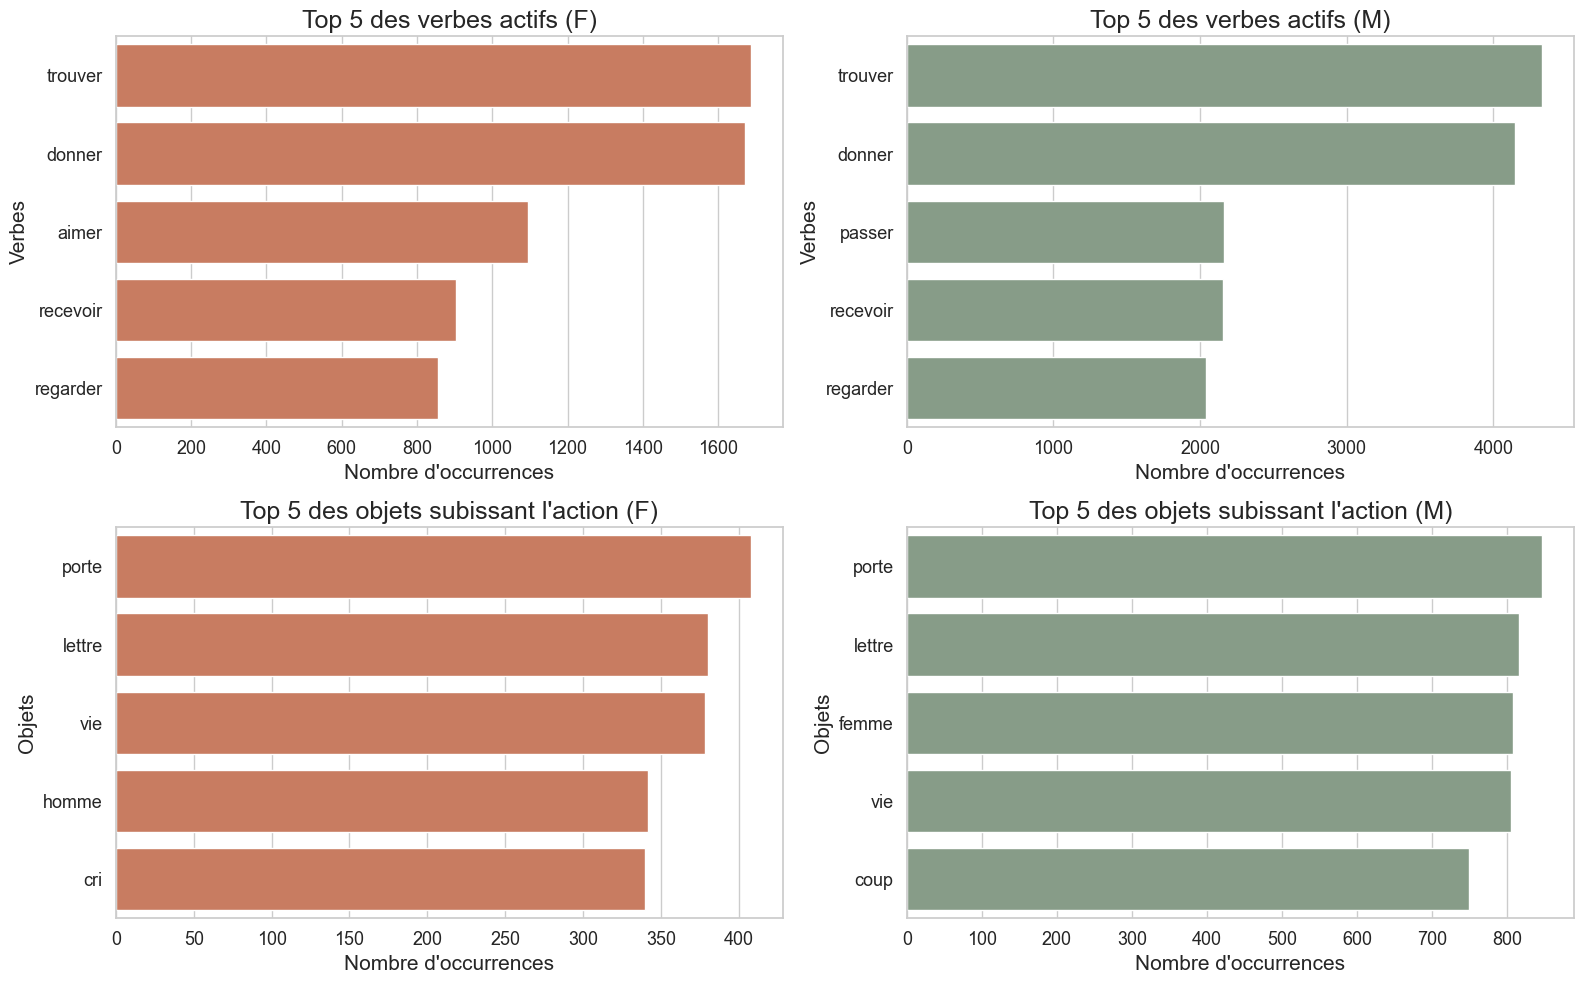

In [36]:
# On ne garde que les lignes où le verbe est agentif
df_actif = df_clean[df_clean['voix'] == 'actif']

# On configure le style général des graphiques
sns.set_theme(style = "whitegrid")
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Définition de couleurs distinctes pour le genre 
couleurs = {'F': '#d97450', 'M': '#83a085'}  

# Calcul des 5 verbes les plus fréquents quand chaque genre est agentif
for i, genre in enumerate(['F', 'M']):
    # Extraction des  verbes
    top_verbes = df_actif[df_actif['sujet_genre'] == genre]['verbe'].value_counts().head(5)
    
    # Création du graphique 
    sns.barplot(
        x = top_verbes.values, 
        y = top_verbes.index, 
        ax = axes[0, i], 
        color = couleurs[genre]
    )
    axes[0, i].set_title(f"Top 5 des verbes actifs ({genre})", fontsize = 18)
    axes[0, i].set_xlabel("Nombre d'occurrences", fontsize = 15)
    axes[0, i].set_ylabel("Verbes", fontsize = 15)
    axes[0, i].tick_params(axis='both', labelsize=13)

# Calcul des 5 objets les plus fréquents quand chaque genre est agentif
for i, genre in enumerate(['F', 'M']):
    # Extraction des objets
    top_objets = df_actif[df_actif['sujet_genre'] == genre]['objet'].value_counts().head(5)
    
    # Création du graphique
    sns.barplot(
        x = top_objets.values, 
        y = top_objets.index, 
        ax = axes[1, i], 
        color = couleurs[genre]
    )
    axes[1, i].set_title(f"Top 5 des objets subissant l'action ({genre})", fontsize = 18)
    axes[1, i].set_xlabel("Nombre d'occurrences", fontsize = 15)
    axes[1, i].set_ylabel("Objets", fontsize = 15)
    axes[1, i].tick_params(axis='both', labelsize=13)


plt.tight_layout()
plt.show()

## 4. Conclusion

Les résultats de cette étude mettent en lumière trois phénomènes particulièrement intéressants. On remarque tout d'abord que les hommes et les femmes n'agissent pas du tout dans les mêmes sphères. Pour les personnages féminins, le top des verbes actifs et des objets subissant l'action décrit un univers  souvent ancré dans l'intériorité, les relations interpersonnelles ou l'espace domestique, et on peut noter l'aspect sentimental féminin avec la présence du verbe aimer. À l'inverse, du côté masculin, la présence du  verbe passer associé à un objet comme coup renvoie davantage à une action extérieure ou  des relations plus physiques  et violentes. Cette divergence montre que si l'agentivité existe grammaticalement des deux côtés, elle s'exprime dans des espaces sociaux et narratifs profondément genrés.

De plus, on observe un écart de visibilité numérique majeur, car sur le plan quantitatif, les personnages masculins s'avèrent largement plus représentés dans le corpus. Ils occupent le rôle de sujet grammatical plus de deux fois plus souvent que les personnages féminins (environ 162 000 à 171 000 occurrences actives pour les hommes contre 67 000 à 72 000 pour les femmes). Cette observation confirme un fort "gender gap" en matière de présence textuelle. 

En revanche, quand on examine les différences d'agentivité entre les genres dans le corpus, la tendance s'inverse. Les personnages féminins affichent un taux de voix active légèrement supérieur à celui des hommes (99,44% contre 99,19%). Le test du Chi-2 nous permet de confirmer que cette différence est hautement significative (p < 0.000). De plus, l'Odds Ratio (entre 1,42 et 1,44 selon les filtres) démontre qu'à occurrence égale, un personnage féminin a environ 1,4 fois plus de chances d'être le sujet d'un verbe à la voix active qu'un personnage masculin.

On peut conclure en observant que l'effacement ou la domination de genre dans ce corpus ne se traduit pas par une réduction des femmes à des rôles de sujets passifs ou subissants lorsqu'elles agissent. Au contraire, quand un auteur choisit une figure féminine comme sujet de la phrase, celle-ci est très intensément motrice de l'action. 
Ainsi, si leur sous-représentation numérique reflète fidèlement la relégation des femmes dans la sphère privée au XIXe siècle, leur forte agentivité grammaticale démontre que la création littéraire ne se contente pas d'être le miroir passif des rapports de domination réels. Elle représente plutôt un espace de négociation et de subversion, où les personnages féminins, dès qu'ils accèdent à la scène textuelle, défient les normes de l'époque en s'affirmant comme de puissantes actrices de leur propre destin.